# **Data Loading**

In [1]:
# Import the required libraries
import pandas as pd

In [2]:
# Load the dataset
df = pd.read_csv('titanic_train.csv')

# Display the dataset
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


# **Data Exploration**

In [3]:
# Basic information about the dataset
print("\nBasic Information:")
print(df.info())


Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [4]:
# Summary Statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [5]:
# Total rows and columns
print("\nTotal rows and columns:")
print(df.shape)


Total rows and columns:
(891, 12)


In [6]:
# Columns with missing values
print("\nColumns with missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Columns with missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [7]:
# Numerical columns list
print("\nNumerical columns:")
print(df.select_dtypes(include="number").columns.tolist())


Numerical columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [8]:
# Categorical columns list
print("\nCategorical columns:")
print(df.select_dtypes(include="object").columns.tolist())


Categorical columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


## **Data Story - First Look at the Titanic Training Dataset**

- The dataset has **891 rows and 12 columns**, each row representing one passenger.
- **Three columns have missing values:** Cabin (687 missing — ~77% of the column), Age (177 missing), and Embarked (2 missing).
- **Numerical columns:** PassengerId, Survived, Pclass, Age, SibSp, Parch, and Fare.
- **Categorical columns:** Name, Sex, Ticket, Cabin, and Embarked.
- `Survived` is the target (0 = did not survive, 1 = survived); overall survival was about 38%.
- `Pclass` is numeric in storage but really a category (1st/2nd/3rd class).
- Biggest data-quality concern: Cabin is mostly empty, so it will likely be dropped.

# **Handling Missing Values**

In [9]:
# Age: fill with median (robust to skew and outliers)
df["Age"] = df["Age"].fillna(df["Age"].median())

# Embarked: only 2 missing — fill with mode (most common port)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin: ~77% missing — too sparse to impute, so drop it
df = df.drop(columns=["Cabin"])

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


### **Missing Value Handling — Justification**
- **Age (177 missing):** filled with the *median*, which is robust to skew so extreme ages don't distort the fill.
- **Embarked (2 missing):** only two values missing, so filled with the *mode* (most common port) — minimal impact.
- **Cabin (687 missing, ~77%):** far too sparse to impute reliably, so the column was *dropped* rather than inventing data for most passengers.

# **Outlier Detection With Box Plot**

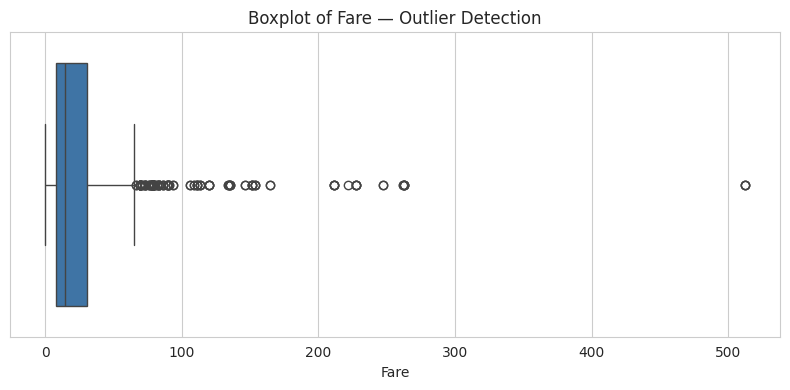

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Box plot for Fare column
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Fare"], color="#2E75B6")
plt.title("Boxplot of Fare — Outlier Detection")
plt.tight_layout()
plt.show()

# **Historgram**

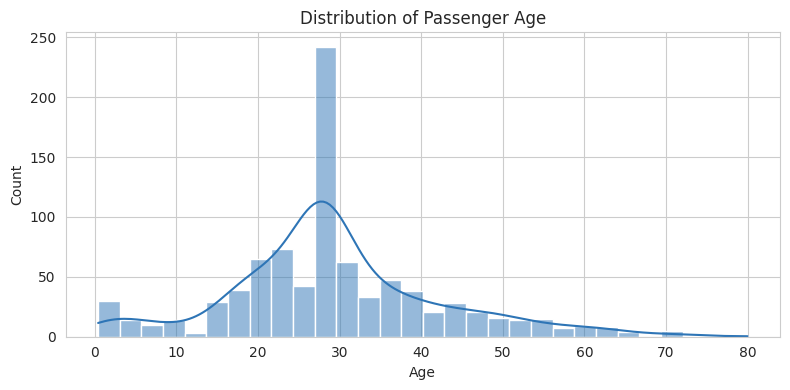

In [11]:
# Histogram for Age column
plt.figure(figsize=(8,4))
sns.histplot(df["Age"], bins=30, kde=True, color="#2E75B6")
plt.title("Distribution of Passenger Age")
plt.tight_layout()
plt.show()

# **Box Plot**

/tmp/ipykernel_1394/2101982808.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Fare", data=df, palette="Blues")


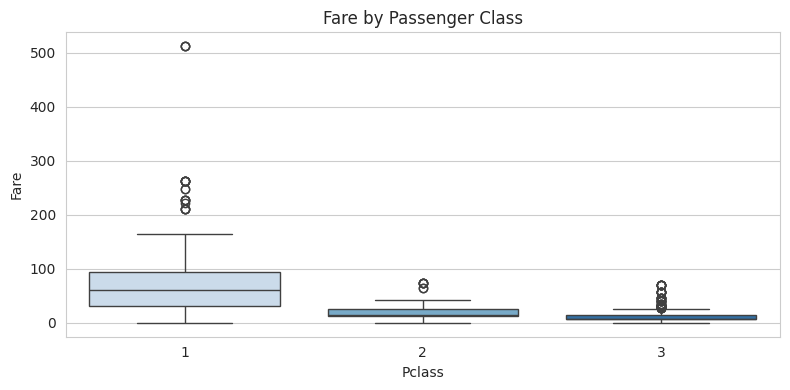

In [12]:
# Box plot for Fare by Class
plt.figure(figsize=(8,4))
sns.boxplot(x="Pclass", y="Fare", data=df, palette="Blues")
plt.title("Fare by Passenger Class")
plt.tight_layout()
plt.show()

# **Bar Chart**

/tmp/ipykernel_1394/1149134295.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df, palette="Blues")


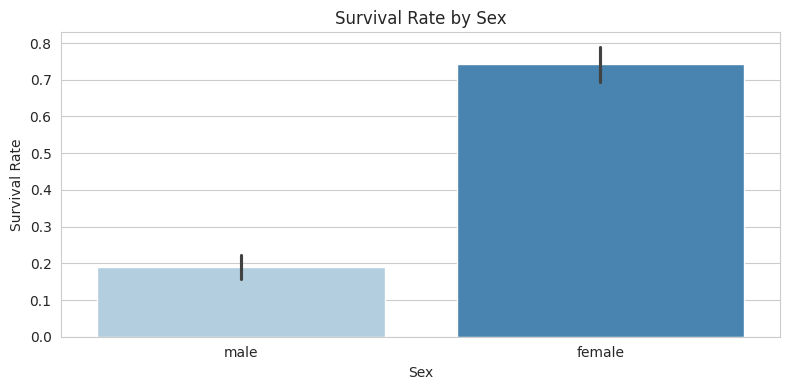

In [13]:
# Bar chart for Survival Rate by Sex
plt.figure(figsize=(8,4))
sns.barplot(x="Sex", y="Survived", data=df, palette="Blues")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

# **Correlation Heatmap**

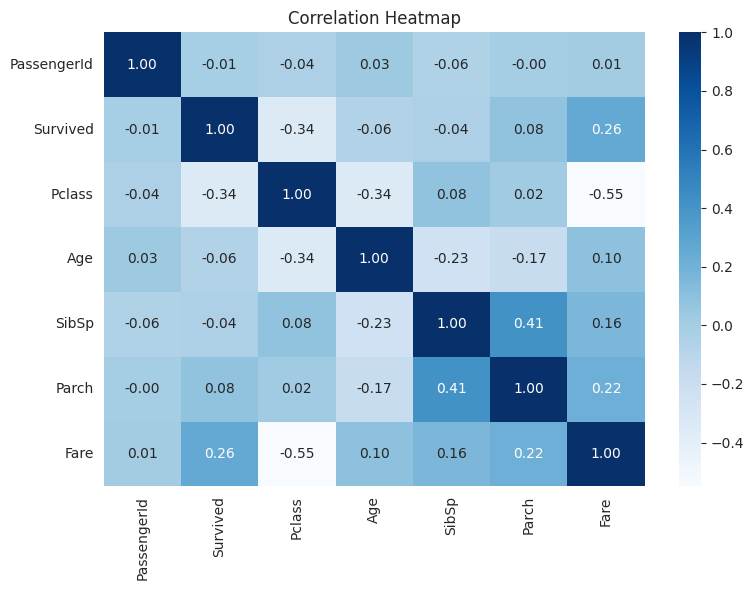

In [14]:
# Correlation heatmap for numerical columns only
plt.figure(figsize=(8,6))
numeric = df.select_dtypes(include="number")
sns.heatmap(numeric.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### **Which feature most affects survival, and why?**

**Sex is the feature that most affects survival.** In this dataset, **74.2% of women survived versus only 18.9% of men** — a dramatic gap reflecting the "women and children first" evacuation.

Passenger class is the second strongest factor: **1st class survived at 63%, 2nd at 47%, 3rd at just 24%**, and Pclass has the strongest *numeric* correlation with survival (-0.34, negative because a lower class number means higher status). Fare shows a similar but weaker effect (+0.26), mostly because higher fares track with higher class.

So survival was driven mainly by **who you were (sex) and how wealthy you were (class/fare)** — not by age, which showed almost no correlation (-0.08).

# **Feature Selection**

In [15]:
# Droping the columns that don't help with prediction
drop_cols = ["PassengerId", "Name", "Ticket"]
model_df = df.drop(columns=drop_cols)

print("Columns used for modeling:")
print(model_df.columns.tolist())

Columns used for modeling:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


# **Encoding**

In [16]:
# One-hot encode the categorical columns
model_df = pd.get_dummies(model_df, columns=["Sex", "Embarked"], drop_first=True)

print("Columns after encoding:")
print(model_df.columns.tolist())
model_df.head()

Columns after encoding:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


# **Train-Test Split**

In [17]:
from sklearn.model_selection import train_test_split

# Separate features (X) from the target (y)
X = model_df.drop(columns=["Survived"])
y = model_df["Survived"]

# 80/20 split. random_state fixes the split for reproducibility.
# stratify=y keeps the survived/died ratio the same in train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)

Training set: (712, 8)
Test set:     (179, 8)


# **Model Training**

In [18]:
from sklearn.linear_model import LogisticRegression

# max_iter raised from the default 100 so the solver fully converges
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


# **Model Evaluation**

In [19]:
from sklearn.metrics import accuracy_score

# Predict on the unseen test set
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")

Accuracy: 0.8045  (80.45%)


# **Confusion Matrix**

Confusion Matrix:
[[98 12]
 [23 46]]


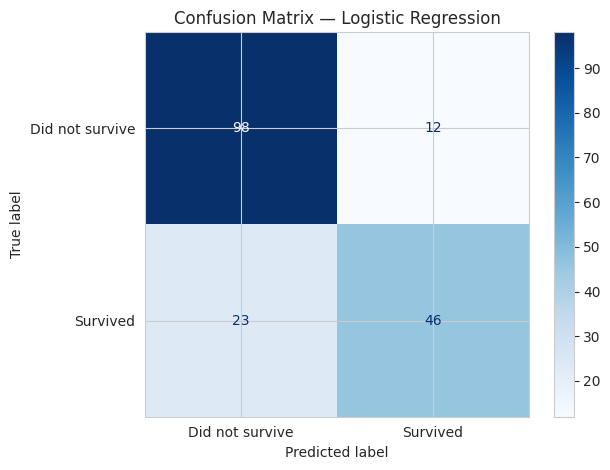

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

## **What the Confusion Matrix Tells Us**

The matrix compares predictions against actual outcomes for the 179 test passengers.
Rows are the true class, columns are what the model predicted:

|                    | Predicted: Did not survive | Predicted: Survived |
|--------------------|:--------------------------:|:-------------------:|
| **Actually died**  | **98** (True Negative)     | 12 (False Positive) |
| **Actually survived** | 23 (False Negative)     | **46** (True Positive) |

- **98 True Negatives** — correctly predicted passengers who died.
- **46 True Positives** — correctly predicted passengers who survived.
- **12 False Positives** — predicted "survived" but they actually died.
- **23 False Negatives** — predicted "died" but they actually survived.

**Total correct = 98 + 46 = 144 out of 179 → 80.45% accuracy**, matching the score above.

**What it reveals:** the model is noticeably better at identifying non-survivors
(98 of 110 correct, ~89% recall) than survivors (46 of 69 correct, ~67% recall).
The 23 false negatives are the main weakness — nearly a third of actual survivors
were missed. This is a common effect of class imbalance: with more non-survivors
in the data, the model leans slightly toward predicting "did not survive."
Accuracy alone hides this, which is exactly why the confusion matrix matters.

# **Metrics**

In [21]:
from sklearn.metrics import classification_report

print("Classification Report — Baseline Logistic Regression\n")
print(classification_report(
    y_test, y_pred,
    target_names=["Did not survive", "Survived"],
    digits=4
))

Classification Report — Baseline Logistic Regression

                 precision    recall  f1-score   support

Did not survive     0.8099    0.8909    0.8485       110
       Survived     0.7931    0.6667    0.7244        69

       accuracy                         0.8045       179
      macro avg     0.8015    0.7788    0.7864       179
   weighted avg     0.8034    0.8045    0.8007       179



### **Why Accuracy Alone Can Be Misleading on Imbalanced Datasets**

Accuracy asks a single blunt question: *out of all predictions, what fraction were
correct?* It treats every mistake as equally important and averages across all
classes. When one class dominates the data, that average gets swamped by whichever
class is bigger, and the model's failures on the smaller class become invisible.

Our dataset is imbalanced, 549 died vs 342 survived (about 62/38). A model that
simply predicted "did not survive" for **every single passenger**, learning nothing
at all, would still score **61.45% accuracy** on our test set. That is the floor.
Any accuracy score has to be judged against that floor, not against zero, and
suddenly 80.45% looks far less impressive than it first appears.

The problem gets much worse as imbalance grows. In fraud detection where 1 in 1,000
transactions is fraudulent, a model that flags nothing is **99.9% accurate** and
completely worthless. The accuracy number is technically true and practically
meaningless.

Accuracy also hides *which kind* of error the model makes, and in most real problems
the two errors cost very different amounts. Our model produces 23 false negatives
(actual survivors classified as dead) versus only 12 false positives. In a rescue
scenario, missing a survivor is far more costly than a false alarm but accuracy
weighs those two mistakes identically. Precision, recall, and the per-class F1 break
the score apart by class and error type, exposing the weakness that the single
accuracy figure conceals.

# **Hyperparameters Tuning**

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Scaler + model bundled so scaling happens inside each CV fold (no leakage)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(solver="liblinear", max_iter=1000, random_state=42))
])

# Note the "lr__" prefix — it targets the 'lr' step inside the pipeline
param_grid = {
    "lr__C":            [0.001, 0.01, 0.1, 1, 10, 100],
    "lr__penalty":      ["l1", "l2"],
    "lr__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,                 # 5-fold cross-validation
    scoring="f1",         # optimize F1 of the Survived class, not accuracy
    n_jobs=-1,            # use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters:", grid_search.best_params_)
print(f"Best cross-validated F1: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'lr__C': 10, 'lr__class_weight': 'balanced', 'lr__penalty': 'l1'}
Best cross-validated F1: 0.7314


# **Tuned Model Evaluation**

Classification Report — Tuned Model

                 precision    recall  f1-score   support

Did not survive     0.8571    0.8182    0.8372       110
       Survived     0.7297    0.7826    0.7552        69

       accuracy                         0.8045       179
      macro avg     0.7934    0.8004    0.7962       179
   weighted avg     0.8080    0.8045    0.8056       179

Tuned Confusion Matrix:
[[90 20]
 [15 54]]


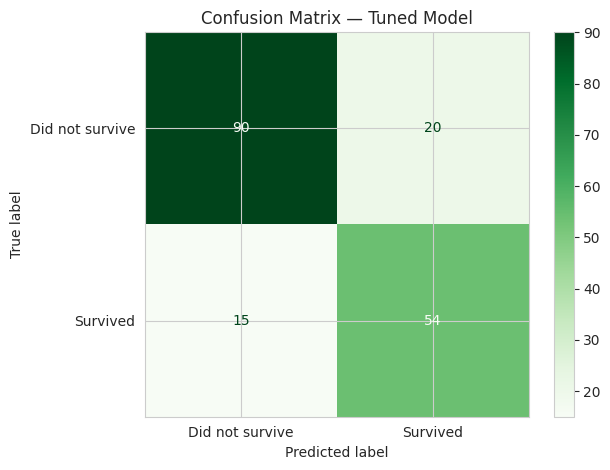

In [23]:
# GridSearchCV automatically refits the best model on the full training set
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

print("Classification Report — Tuned Model\n")
print(classification_report(
    y_test, y_pred_tuned,
    target_names=["Did not survive", "Survived"],
    digits=4
))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("Tuned Confusion Matrix:")
print(cm_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned,
                              display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix — Tuned Model")
plt.tight_layout()
plt.show()

# **Before / After Table**

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred_):
    return {
        "Accuracy":              accuracy_score(y_true, y_pred_),
        "Precision (Survived)":  precision_score(y_true, y_pred_),
        "Recall (Survived)":     recall_score(y_true, y_pred_),
        "F1-Score (Survived)":   f1_score(y_true, y_pred_),
        "Macro F1":              f1_score(y_true, y_pred_, average="macro"),
    }

comparison = pd.DataFrame({
    "Before (Baseline)": get_metrics(y_test, y_pred),
    "After (Tuned)":     get_metrics(y_test, y_pred_tuned),
}).round(4)

comparison["Change"] = (comparison["After (Tuned)"]
                        - comparison["Before (Baseline)"]).round(4)

print("Before / After Comparison\n")
print(comparison)

Before / After Comparison

                      Before (Baseline)  After (Tuned)  Change
Accuracy                         0.8045         0.8045  0.0000
Precision (Survived)             0.7931         0.7297 -0.0634
Recall (Survived)                0.6667         0.7826  0.1159
F1-Score (Survived)              0.7244         0.7552  0.0308
Macro F1                         0.7864         0.7962  0.0098


### **Before / After Comparison**

| Metric | Before (Baseline) | After (Tuned) | Change |
|--------|:-----------------:|:-------------:|:------:|
| Accuracy | 0.8045 | 0.8045 | **0.0000** |
| Precision (Survived) | 0.7931 | 0.7297 | −0.0634 |
| Recall (Survived) | 0.6667 | **0.7826** | **+0.1159** |
| F1-Score (Survived) | 0.7244 | **0.7552** | **+0.0308** |
| Macro F1 | 0.7864 | **0.7962** | **+0.0098** |

### **Confusion Matrices Side By Side:**

| | Baseline | Tuned |
|---|:---:|:---:|
| True Negatives | 98 | 90 |
| False Positives | 12 | 20 |
| **False Negatives** | **23** | **15** |
| True Positives | 46 | 54 |

### **What Changed And Why It Matters**

**Accuracy did not move at all as it is 0.8045 both before and after.** Judged on
accuracy alone, the tuning session was a complete waste of time. That conclusion
would be wrong, and this is the clearest possible demonstration of the point made
earlier: accuracy is blind to changes in *how* a model distributes its errors.

Underneath that unchanged number, the model improved meaningfully. **Recall on the
Survived class rose from 0.6667 to 0.7826** so false negatives dropped from 23 to 15,
so the model now finds 8 more of the passengers who actually survived. F1 for that
class rose from 0.7244 to 0.7552, and macro F1 improved as well.

This came at a real cost: **precision fell from 0.7931 to 0.7297**, as false
positives rose from 12 to 20. This is the classic precision/recall trade-off. The
`class_weight='balanced'` setting instructs the model to take the minority class more
seriously, so it predicts "survived" more readily, catching more true survivors while
also raising more false alarms. F1 rising confirms the trade was worthwhile overall.

Whether this tuned model is genuinely "better" depends on the cost of each error
type. For a rescue-planning use case, where missing a survivor is far worse than
investigating a false lead, the improved recall is clearly the better trade. For a
use case where every positive prediction triggers an expensive investigation, the
baseline's higher precision might be preferable. **Neither the accuracy score nor
any single metric can make that call as it is a domain decision, informed by the
full classification report.**